# Nettoyage minimal + régression baseline — french-second-hand-cars

Dataset gardé (verdict EDA). Objectif : **premier point de repère** de prédiction du prix.

**Choix actés :**
- On retire les **électriques purs** (40) — colonnes batterie vides, prix parfois hors batterie (location). Les hybrides restent (batterie toujours incluse → prix comparable).
- Une fois les électriques partis, `prixinclutlabatterie` n'a plus de valeur `non location` : elle devient constante (hybride = batterie incluse) → **colonne abandonnée**.
- Nettoyage **minimal** : parser price + colonnes numériques sales, écrire un fichier `processed/` (le `raw/` reste intact).
- Baseline calquée sur le TP `Evaluation_regression.ipynb` : `LinearRegression` + MAE/MSE/RMSE/R².

> La baseline est un **repère**, pas un choix de modèle. L'exigence produit « fourchette + incertitude » viendra ensuite.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

RAW = Path("../../data/french-second-hand-cars/raw/French_second_hand_cars.csv")
df = pd.read_csv(RAW)
print("brut:", df.shape)

brut: (2441, 40)


## 1. Nettoyage minimal

In [2]:
def to_num(serie):
    """Extrait un nombre d'une colonne texte sale ('27 297 Km', '11 080 €', '90 ch')."""
    return pd.to_numeric(
        serie.astype(str)
             .str.replace(r"[^\d,.-]", "", regex=True)   # garde chiffres . , -
             .str.replace(",", ".", regex=False)
             .replace("", np.nan),
        errors="coerce",
    )

clean = df.copy()

# a) retirer les électriques purs (garde hybrides)
clean["énergie"] = clean["énergie"].astype(str).str.strip()
n_elec = (clean["énergie"] == "Electrique").sum()
clean = clean[clean["énergie"] != "Electrique"].copy()
print(f"électriques purs retirés : {n_elec}")

# b) parser la cible + les numériques
clean["price"]          = to_num(clean["price"])
clean["kilometrage"]    = to_num(clean["kilométragecompteur"])
clean["puissance_din"]  = to_num(clean["puissancedin"])
clean["puissance_fisc"] = to_num(clean["puissancefiscale"])
clean["annee"]          = pd.to_numeric(clean["année"], errors="coerce")

# c) garde-fous : prix valide, année plausible
clean = clean[clean["price"].notna()]
clean = clean[clean["annee"].between(1980, 2026)]
print("après nettoyage:", clean.shape)

électriques purs retirés : 40
après nettoyage: (2340, 44)


In [3]:
# Écriture du fichier processed (raw jamais modifié)
PROC = Path("../../data/french-second-hand-cars/processed")
PROC.mkdir(parents=True, exist_ok=True)
cols_keep = ["price","annee","kilometrage","puissance_din","puissance_fisc",
             "nombredeportes","nombredeplaces","énergie","boîtedevitesse",
             "carmodel","departement"]
clean[cols_keep].to_csv(PROC / "cars_clean.csv", index=False)
print("écrit:", PROC / "cars_clean.csv")

écrit: ../../data/french-second-hand-cars/processed/cars_clean.csv


## 2. Baseline — régression linéaire

Features **numériques simples** (comme le TP). On enlève les lignes incomplètes sur ces colonnes.

In [4]:
features = ["annee", "kilometrage", "puissance_din", "puissance_fisc",
            "nombredeportes", "nombredeplaces"]
data = clean[features + ["price"]].dropna()
print(f"lignes utilisables : {len(data)} / {len(clean)}")

X = data[features]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)

lignes utilisables : 2229 / 2340
train: (1783, 6) | test: (446, 6)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 3. Métriques (comme le TP)

In [6]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.0f} €   (erreur absolue moyenne)")
print(f"RMSE : {rmse:,.0f} €   (pénalise les grosses erreurs)")
print(f"R²   : {r2:.3f}        (part de variance expliquée, 1 = parfait)")

MAE  : 7,711 €   (erreur absolue moyenne)
RMSE : 14,815 €   (pénalise les grosses erreurs)
R²   : 0.717        (part de variance expliquée, 1 = parfait)


In [7]:
# Poids appris (interprétabilité — atout du modèle linéaire)
coefs = pd.Series(model.coef_, index=features).sort_values()
print("Effet estimé sur le prix (€ par unité) :")
print(coefs.round(1))
print(f"\nintercept : {model.intercept_:,.0f} €")

Effet estimé sur le prix (€ par unité) :
nombredeportes   -2573.0
kilometrage         -0.1
puissance_din      213.0
nombredeplaces     342.8
puissance_fisc     391.7
annee             1782.9
dtype: float64

intercept : -3,590,652 €


## 4. Réel vs prédit

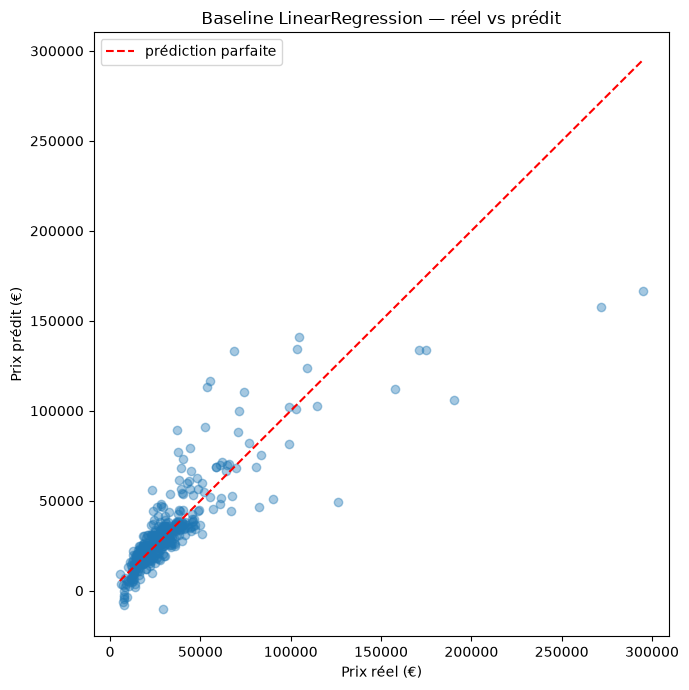

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="prédiction parfaite")
plt.xlabel("Prix réel (€)")
plt.ylabel("Prix prédit (€)")
plt.title("Baseline LinearRegression — réel vs prédit")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Lecture (STOP)

Résultat = **repère**, pas un modèle validé. Limites attendues :
- Modèle linéaire sur 6 features → capture mal la dépréciation (non linéaire).
- `carmodel` (585 modèles) et la marque ignorés → gros levier manquant.
- Pas encore d'incertitude / fourchette (exigence produit à venir).